# BOLD5000 fMRI MLP Attempt
This notebook covers extracting voxel-wise visual ROI data, training an fMRI Autoencoder, and running an RSA against CLIP embeddings.

In [29]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from scipy.stats import spearmanr
from scipy.spatial.distance import pdist, squareform

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [30]:
# Constants
SUBJECT = "CSI4" # Configurable to switch subjects
HDD_DIR = "/media/hdd/BOLD5000"
PROCESSED_DIR = "./processed_data"

# Ensure processed directory exists for the subject
os.makedirs(os.path.join(PROCESSED_DIR, SUBJECT), exist_ok=True)

# List of target visual ROIs we want to extract
# From the GLMsingle ROI betas, we saw regions like LHEarlyVis, RHEarlyVis, LHLOC, RHLOC, LHOPA, RHOPA, LHPPA, RHPPA, LHRSC, RHRSC
TARGET_ROIS = [
    "LHEarlyVis", "RHEarlyVis",
    "LHLOC", "RHLOC",
    "LHOPA", "RHOPA",
    "LHPPA", "RHPPA",
    "LHRSC", "RHRSC"
]

# We are using TYPE D which id best estimate per paper
BETA_TYPE = "TYPED-FITHRF-GLMDENOISE-RR"

## Preprocess Data ##

In [ ]:
# Extract relevant ROIs directly from the ZIP
import zipfile
import re
import json

# --- Label mapping helpers (mirrors preprocess.py) ---
def _load_imagenet_synset_to_label(mappings_dir: str) -> dict:
    inet_path = os.path.join(mappings_dir, "imagenet_class_index.json")
    if not os.path.exists(inet_path):
        raise FileNotFoundError(
            f"Missing {inet_path}. Run preprocess.py once (it downloads it), "
            "or place imagenet_class_index.json in label_mappings/."
        )
    with open(inet_path, "r") as f:
        raw = json.load(f)
    # raw: idx -> [synset, label]
    return {v[0]: v[1] for v in raw.values()}


def _load_coco_img_to_categories(mappings_dir: str) -> dict:
    coco_path = os.path.join(mappings_dir, "instances_train2014.json")
    if not os.path.exists(coco_path):
        raise FileNotFoundError(
            f"Missing {coco_path}. Run preprocess.py once (it downloads it), "
            "or place instances_train2014.json in label_mappings/."
        )
    with open(coco_path, "r") as f:
        coco_data = json.load(f)
    cat_id_to_name = {cat["id"]: cat["name"] for cat in coco_data["categories"]}
    img_to_cats = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        cat_name = cat_id_to_name.get(ann["category_id"], "unknown")
        if img_id not in img_to_cats:
            img_to_cats[img_id] = []
        if cat_name not in img_to_cats[img_id]:
            img_to_cats[img_id].append(cat_name)
    return img_to_cats


def _resolve_labels_for_filename(filename: str, imagenet_synset_to_label: dict, coco_img_to_categories: dict):
    """Return (dataset_source, labels:list[str]) for a stimulus filename."""
    basename = os.path.basename(filename)

    # ImageNet: starts with n followed by digits, then underscore
    if re.match(r'^n\d+_', basename):
        synset = basename.split('_')[0]
        label = imagenet_synset_to_label.get(synset, synset)
        return "ImageNet", [label]

    # COCO: filename contains 'COCO'
    if "COCO" in basename:
        m = re.search(r'(\d{6,12})', basename)
        img_id = int(m.group(1)) if m else -1
        cats = coco_img_to_categories.get(img_id, [])
        return "COCO", cats if cats else [f"COCO image {img_id}"]

    # Scene / SUN / other
    scene = os.path.splitext(basename)[0]
    scene = re.sub(r'\d+', '', scene)
    scene = re.sub(r'([a-z])([A-Z])', r'\1 \2', scene)
    return "Scene", [scene.strip().title() or basename]


def build_trial_labels(img_names: list[str]):
    """Build arrays: dataset_sources (N,), labels (N,) (object list[str])."""
    mappings_dir = os.path.join("..", "label_mappings")
    imagenet_synset_to_label = _load_imagenet_synset_to_label(mappings_dir)
    coco_img_to_categories = _load_coco_img_to_categories(mappings_dir)

    dataset_sources = []
    labels = []
    for name in img_names:
        src, lbs = _resolve_labels_for_filename(name, imagenet_synset_to_label, coco_img_to_categories)
        dataset_sources.append(src)
        labels.append(lbs)
    return np.array(dataset_sources), np.array(labels, dtype=object)


def parse_and_save_rois(subject):
    print(f"Extracting and merging ROI data for {subject}...")
    zip_path = os.path.join(HDD_DIR, "BOLD5000_GLMsingle_ROI_betas.zip")

    subject_rois = {}

    with zipfile.ZipFile(zip_path, 'r') as z:
        # Get all relevant .npy files
        files = [f for f in z.namelist() if f.endswith('.npy') and f"/{subject}_" in f and BETA_TYPE in f]

        for roi in TARGET_ROIS:
            roi_file = next((f for f in files if roi in f), None)
            if roi_file:
                with z.open(roi_file) as f:
                    roi_data = np.load(f)
                    subject_rois[roi] = roi_data
                    print(f"Loaded {roi} | Shape: {roi_data.shape}")
            else:
                print(f"Warning: {roi} not found for {subject}")

    # Concatenate all ROI matrices horizontally (Trial x Voxel)
    concat_list = []
    roi_indices_map = {}
    current_idx = 0

    for roi in TARGET_ROIS:
        if roi in subject_rois:
            mat = subject_rois[roi]
            num_voxels = mat.shape[1]
            concat_list.append(mat)
            roi_indices_map[roi] = (current_idx, current_idx + num_voxels)
            current_idx += num_voxels

    all_visual_voxels = np.concatenate(concat_list, axis=1)
    print(f"\nFinal Concatenated Shape ({subject}): {all_visual_voxels.shape}")

    # Load stimulus order for this subject
    imgnames_path = os.path.join(HDD_DIR, f"{subject}_imgnames.txt")
    with open(imgnames_path, 'r') as f:
        img_names = [line.strip() for line in f.readlines()]
    print(f"Loaded {len(img_names)} image names for {subject}.")

    # NEW: build labels + dataset sources and save them alongside the ROI betas
    print("Building per-trial labels (ImageNet/COCO/Scene)...")
    dataset_sources, labels = build_trial_labels(img_names)
    print("Label mapping complete.")

    # Save into ./processed_data/<participant>/ (e.g., ./processed_data/CSI1/CSI1_visual_rois.npz)
    out_dir = os.path.join(PROCESSED_DIR, subject)
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"{subject}_visual_rois.npz")
    np.savez_compressed(
        out_path,
        betas=all_visual_voxels,
        imgnames=np.array(img_names),
        roi_mapping=roi_indices_map,
        dataset_sources=dataset_sources,
        labels=labels,
    )
    print(f"Saved optimized data to: {out_path}\n")
    return all_visual_voxels, img_names, roi_indices_map

# Run extraction for our selected target subject
betas, imgnames, roi_map = parse_and_save_rois(SUBJECT)

Extracting and merging ROI data for CSI4...
Loaded LHEarlyVis | Shape: (3108, 408)
Loaded RHEarlyVis | Shape: (3108, 356)
Loaded LHLOC | Shape: (3108, 455)
Loaded RHLOC | Shape: (3108, 417)
Loaded LHOPA | Shape: (3108, 279)
Loaded RHOPA | Shape: (3108, 335)
Loaded LHPPA | Shape: (3108, 157)
Loaded RHPPA | Shape: (3108, 187)
Loaded LHRSC | Shape: (3108, 51)
Loaded RHRSC | Shape: (3108, 142)

Final Concatenated Shape (CSI4): (3108, 2787)
Loaded 3108 image names for CSI4.
Building per-trial labels (ImageNet/COCO/Scene)...
Label mapping complete.
Label mapping complete.
Saved optimized data to: ./processed_data/CSI4/CSI4_visual_rois.npz

Saved optimized data to: ./processed_data/CSI4/CSI4_visual_rois.npz



In [32]:
# --- Sanity-check saved processed ROI files for all subjects (CSI1–CSI4) ---
import numpy as np
from collections import Counter

def _load_roi_npz(subject: str, processed_root: str = "./processed_data"):
    path = os.path.join(processed_root, subject, f"{subject}_visual_rois.npz")
    if not os.path.exists(path):
        return path, None
    return path, np.load(path, allow_pickle=True)

def _roi_list(roi_mapping):
    if roi_mapping is None:
        return []
    if isinstance(roi_mapping, np.ndarray):  # sometimes comes as 0-d array containing a dict
        try:
            roi_mapping = roi_mapping.item()
        except Exception:
            pass
    if isinstance(roi_mapping, dict):
        return sorted(list(roi_mapping.keys()))
    return []

subjects = ["CSI1", "CSI2", "CSI3", "CSI4"]
loaded = {}
for s in subjects:
    path, npz = _load_roi_npz(s, processed_root=PROCESSED_DIR)
    loaded[s] = (path, npz)

print("=" * 90)
print("Processed ROI files (expected: one per subject in ./processed_data/<SUBJECT>/)")
print("=" * 90)
for s in subjects:
    path, npz = loaded[s]
    print(f"\n{s}: {path}")
    if npz is None:
        print("  [MISSING] not found")
        continue
    keys = list(npz.keys())
    betas = npz["betas"] if "betas" in npz else None
    imgnames = npz["imgnames"] if "imgnames" in npz else None
    labels = npz["labels"] if "labels" in npz else None
    sources = npz["dataset_sources"] if "dataset_sources" in npz else None
    roi_mapping = npz["roi_mapping"] if "roi_mapping" in npz else None

    print(f"  keys: {keys}")
    if betas is not None:
        print(f"  betas   : {betas.shape}")
    if imgnames is not None:
        print(f"  imgnames: {imgnames.shape}")
    if labels is not None:
        print(f"  labels  : {labels.shape}  dtype={labels.dtype}")
    if sources is not None:
        try:
            c = Counter([str(x) for x in sources.tolist()])
            print("  sources : " + ", ".join([f"{k}={v}" for k, v in sorted(c.items())]))
        except Exception:
            print(f"  sources : {sources.shape}")

    rois = _roi_list(roi_mapping)
    print(f"  #ROIs   : {len(rois)}")
    if rois:
        print(f"  ROIs    : {rois}")

# Compare ROI presence across subjects (helps explain voxel-dim differences)
roi_sets = {s: set(_roi_list(loaded[s][1]["roi_mapping"]) if loaded[s][1] is not None and "roi_mapping" in loaded[s][1] else []) for s in subjects}
all_rois = sorted(set().union(*roi_sets.values()))
print("\n" + "=" * 90)
print("ROI presence table (1=present, 0=missing)")
print("=" * 90)
header = "ROI".ljust(20) + " " + " ".join([s.rjust(5) for s in subjects])
print(header)
print("-" * len(header))
for roi in all_rois:
    row = roi.ljust(20) + " " + " ".join([("1" if roi in roi_sets[s] else "0").rjust(5) for s in subjects])
    print(row)

Processed ROI files (expected: one per subject in ./processed_data/<SUBJECT>/)

CSI1: ./processed_data/CSI1/CSI1_visual_rois.npz
  keys: ['betas', 'imgnames', 'roi_mapping', 'dataset_sources', 'labels']
  betas   : (5254, 1685)
  imgnames: (5254,)
  labels  : (5254,)  dtype=object
  sources : COCO=2135, ImageNet=2051, Scene=1068
  #ROIs   : 10
  ROIs    : ['LHEarlyVis', 'LHLOC', 'LHOPA', 'LHPPA', 'LHRSC', 'RHEarlyVis', 'RHLOC', 'RHOPA', 'RHPPA', 'RHRSC']

CSI2: ./processed_data/CSI2/CSI2_visual_rois.npz
  keys: ['betas', 'imgnames', 'roi_mapping', 'dataset_sources', 'labels']
  betas   : (5254, 1104)
  imgnames: (5254,)
  labels  : (5254,)  dtype=object
  sources : COCO=2135, ImageNet=2051, Scene=1068
  #ROIs   : 7
  ROIs    : ['LHEarlyVis', 'LHOPA', 'LHPPA', 'LHRSC', 'RHEarlyVis', 'RHOPA', 'RHPPA']

CSI3: ./processed_data/CSI3/CSI3_visual_rois.npz
  keys: ['betas', 'imgnames', 'roi_mapping', 'dataset_sources', 'labels']
  betas   : (5254, 1466)
  imgnames: (5254,)
  labels  : (5254,) 

In [40]:
# Quickly check the RAW fMRI beta files in /media/hdd/BOLD5000 (one per subject/session)
# and see whether the *raw* data shape differs across participants.
# This helps decide if differences are inherent to the raw files vs our ROI preprocessing.

import os
import nibabel as nib
from collections import defaultdict

def raw_beta_path(subject: str, session: int) -> str:
    return os.path.join(
        HDD_DIR,
        f"{subject}_GLMbetas-TYPED-FITHRF-GLMDENOISE-RR_ses-{session:02d}.nii.gz",
    )

subjects = ["CSI1", "CSI2", "CSI3", "CSI4"]
subject_sessions = {
    "CSI1": list(range(1, 16)),
    "CSI2": list(range(1, 16)),
    "CSI3": list(range(1, 16)),
    "CSI4": list(range(1, 10)),  # CSI4 often has fewer sessions available
}

print("=" * 100)
print("RAW GLM beta NIfTI shapes per subject/session")
print("(format: (X, Y, Z, N_trials))")
print("=" * 100)

summary = {}
missing = []
for subj in subjects:
    seshs = subject_sessions.get(subj, [])
    shapes = []
    trial_counts = []
    xyz_shapes = set()
    print(f"\n{subj}:")
    for sesh in seshs:
        p = raw_beta_path(subj, sesh)
        if not os.path.exists(p):
            print(f"  ses-{sesh:02d}: [MISSING] {p}")
            missing.append((subj, sesh, p))
            continue
        try:
            img = nib.load(p)
            shp = tuple(img.shape)
        except Exception as e:
            print(f"  ses-{sesh:02d}: [ERROR] {e}")
            continue

        # Expect 4D beta volumes: (X, Y, Z, trials)
        if len(shp) != 4:
            print(f"  ses-{sesh:02d}: shape={shp}  [WARN] expected 4D")
            continue
        x, y, z, n_trials = shp
        print(f"  ses-{sesh:02d}: shape={shp}")
        shapes.append(shp)
        trial_counts.append(n_trials)
        xyz_shapes.add((x, y, z))

    # Per-subject summary
    if shapes:
        uniq_xyz = sorted(list(xyz_shapes))
        summary[subj] = {
            "n_sessions_found": len(shapes),
            "xyz_shapes": uniq_xyz,
            "trial_counts": trial_counts,
            "total_trials": int(sum(trial_counts)),
        }
        print("  --")
        print(f"  sessions found : {summary[subj]['n_sessions_found']} / {len(seshs)}")
        print(f"  unique XYZ grids: {uniq_xyz}")
        print(f"  total trials   : {summary[subj]['total_trials']}")
        if len(set(trial_counts)) > 1:
            # this is normal, but useful to see
            print(f"  trial count range: {min(trial_counts)}–{max(trial_counts)}")
    else:
        summary[subj] = {
            "n_sessions_found": 0,
            "xyz_shapes": [],
            "trial_counts": [],
            "total_trials": 0,
        }

print("\n" + "=" * 100)
print("COMPARISON SUMMARY")
print("=" * 100)
for subj in subjects:
    s = summary[subj]
    print(f"{subj}: sessions_found={s['n_sessions_found']} total_trials={s['total_trials']} xyz_grids={s['xyz_shapes']}")

if missing:
    print("\n" + "=" * 100)
    print(f"Missing files ({len(missing)}):")
    print("=" * 100)
    # print only a few examples to keep output readable
    for (subj, sesh, p) in missing[:10]:
        print(f"  {subj} ses-{sesh:02d}: {p}")
    if len(missing) > 10:
        print(f"  ... and {len(missing) - 10} more")

RAW GLM beta NIfTI shapes per subject/session
(format: (X, Y, Z, N_trials))

CSI1:
  ses-01: shape=(71, 89, 72, 370)
  ses-02: shape=(71, 89, 72, 370)
  ses-03: shape=(71, 89, 72, 370)
  ses-04: shape=(71, 89, 72, 333)
  ses-05: shape=(71, 89, 72, 370)
  ses-06: shape=(71, 89, 72, 333)
  ses-07: shape=(71, 89, 72, 370)
  ses-08: shape=(71, 89, 72, 333)
  ses-09: shape=(71, 89, 72, 333)
  ses-10: shape=(71, 89, 72, 370)
  ses-11: shape=(71, 89, 72, 333)
  ses-12: shape=(71, 89, 72, 333)
  ses-13: shape=(71, 89, 72, 333)
  ses-14: shape=(71, 89, 72, 333)
  ses-15: shape=(71, 89, 72, 370)
  --
  sessions found : 15 / 15
  unique XYZ grids: [(71, 89, 72)]
  total trials   : 5254
  trial count range: 333–370

CSI2:
  ses-01: shape=(72, 92, 70, 370)
  ses-02: shape=(72, 92, 70, 333)
  ses-03: shape=(72, 92, 70, 370)
  ses-04: shape=(72, 92, 70, 370)
  ses-05: shape=(72, 92, 70, 370)
  ses-06: shape=(72, 92, 70, 333)
  ses-07: shape=(72, 92, 70, 333)
  ses-08: shape=(72, 92, 70, 333)
  ses-09

# Phase 2: fMRI Autoencoder Model Definition
Here we construct the Multi-Layer Perceptron (MLP) to learn the underlying manifold of the fMRI voxels. The bottleneck layer compresses the structure into exactly 768 continuous dimensions, mimicking the CLIP vector properties!

In [33]:
import torch
import torch.nn as nn

# We build an Encoder and Decorder so we learn to squeeze the fMRI data into 
#768dim vector, matching OpenAI's clip embeddings. 

class fMRI_Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(fMRI_Autoencoder, self).__init__()
        
        # 1685 Voxel regions to 768 bottleneck space.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Dropout(0.5), # fMRI SNR is noisy, heavy dropout generalizes feature extraction.
            
            nn.Linear(2048, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 768) # Bottleneck perfectly matching CLIP Dim!
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(768, 1024),
            nn.LayerNorm(1024),
            nn.GELU(),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 2048),
            nn.LayerNorm(2048),
            nn.GELU(),
            nn.Dropout(0.5),
            
            nn.Linear(2048, input_dim) # Decode back into original brain state.
        )
        
    def forward(self, x):
        bottleneck = self.encoder(x)
        reconstruction = self.decoder(bottleneck)
        return reconstruction, bottleneck

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Active Device: {device}")

Active Device: cuda


In [34]:
from torch.utils.data import TensorDataset, DataLoader, random_split
import glob
import os

# --- 1. Filter out Missing Images --- 
print("Indexing available images from Hard Drive to safely filter trials...")
STIMULI_DIR = os.path.join(HDD_DIR, "BOLD5000_Stimuli/Scene_Stimuli/Presented_Stimuli")
# Recursive grab
available_images_paths = []
for ext in ('*.jpg', '*.JPEG', '*.jpeg', '*.png'):
    available_images_paths.extend(glob.glob(os.path.join(STIMULI_DIR, '**', ext), recursive=True))

image_map = {os.path.basename(p): p for p in available_images_paths}

# Filter out betas that mapped to a missing image
valid_indices = [i for i, name in enumerate(imgnames) if name in image_map]
valid_betas = betas[valid_indices]
valid_imgnames = np.array(imgnames)[valid_indices]

print(f"Original shape: {betas.shape}")
print(f"Valid Shape (found image on disk): {valid_betas.shape}")

# --- 2. Convert to PyTorch & Normalize internally ---
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
valid_betas_scaled = scaler.fit_transform(valid_betas)

# Create full dataset
X_tensor = torch.tensor(valid_betas_scaled, dtype=torch.float32)

dataset = TensorDataset(X_tensor, X_tensor) # Autoencoder tries to map X to X!

# Split (Train / Val / Test)
total_size = len(dataset)
test_size = int(0.1 * total_size)   # 10% test 
val_size = int(0.1 * total_size)    # 10% val
train_size = total_size - val_size - test_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size], generator=generator
)

# Keep track of indices so we can later map to CLIP of original images
test_indices = test_dataset.indices

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Data Split -> Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Indexing available images from Hard Drive to safely filter trials...
Original shape: (3108, 2787)
Valid Shape (found image on disk): (3108, 2787)
Data Split -> Train: 2488, Val: 310, Test: 310
Original shape: (3108, 2787)
Valid Shape (found image on disk): (3108, 2787)
Data Split -> Train: 2488, Val: 310, Test: 310


In [35]:
import torch.optim as optim
import copy

# Initialize model, loss, optimizer
num_voxels = valid_betas_scaled.shape[1]
model = fMRI_Autoencoder(input_dim=num_voxels).to(device)

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5) # AdamW helps regularize

epochs = 100
patience = 10
best_val_loss = float('inf')
early_stop_counter = 0

train_losses = []
val_losses = []

print(f"Starting Training Phase 2 for {SUBJECT} Autoencoder...")

for epoch in range(epochs):
    # --- TRAIN ---
    model.train()
    running_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        
        # Forward
        outputs, _ = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        # Backward
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * batch_x.size(0)
        
    epoch_train_loss = running_train_loss / len(train_dataset)
    train_losses.append(epoch_train_loss)
    
    # --- VALIDATION ---
    model.eval()
    running_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs, _ = model(batch_x)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_x.size(0)
            
    epoch_val_loss = running_val_loss / len(val_dataset)
    val_losses.append(epoch_val_loss)
    
    # Early Stopping Tracking
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        best_model_weights = copy.deepcopy(model.state_dict())
    else:
        early_stop_counter += 1
        
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f} | Patience: {early_stop_counter}/{patience}")
        
    if early_stop_counter >= patience:
        print(f"--- Early Stopping triggered at Epoch {epoch+1} ---")
        break

# Load Best Model
model.load_state_dict(best_model_weights)
print("Training Complete. Retained best weights.")

Starting Training Phase 2 for CSI4 Autoencoder...
Epoch [1/100] | Train MSE: 1.0793 | Val MSE: 0.8827 | Patience: 0/10
Epoch [1/100] | Train MSE: 1.0793 | Val MSE: 0.8827 | Patience: 0/10
Epoch [5/100] | Train MSE: 0.8164 | Val MSE: 0.8060 | Patience: 0/10
Epoch [5/100] | Train MSE: 0.8164 | Val MSE: 0.8060 | Patience: 0/10
Epoch [10/100] | Train MSE: 0.7585 | Val MSE: 0.7491 | Patience: 0/10
Epoch [10/100] | Train MSE: 0.7585 | Val MSE: 0.7491 | Patience: 0/10
Epoch [15/100] | Train MSE: 0.7212 | Val MSE: 0.7191 | Patience: 0/10
Epoch [15/100] | Train MSE: 0.7212 | Val MSE: 0.7191 | Patience: 0/10
Epoch [20/100] | Train MSE: 0.6971 | Val MSE: 0.7012 | Patience: 0/10
Epoch [20/100] | Train MSE: 0.6971 | Val MSE: 0.7012 | Patience: 0/10
Epoch [25/100] | Train MSE: 0.6809 | Val MSE: 0.6896 | Patience: 0/10
Epoch [25/100] | Train MSE: 0.6809 | Val MSE: 0.6896 | Patience: 0/10
Epoch [30/100] | Train MSE: 0.6669 | Val MSE: 0.6811 | Patience: 0/10
Epoch [30/100] | Train MSE: 0.6669 | Val MSE

In [36]:
# --- 4. Evaluate on Test Set & Save the Bottlenecks ---
model.eval()
test_mse = 0.0

extracted_bottlenecks = []
test_image_paths = []

print("Extracting Neural Bottlenecks over Test Set...")
with torch.no_grad():
    for i, (batch_x, batch_y) in enumerate(test_loader):
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        reconstruction, bottleneck = model(batch_x)
        loss = criterion(reconstruction, batch_y)
        test_mse += loss.item() * batch_x.size(0)
        
        extracted_bottlenecks.append(bottleneck.cpu().numpy())
        
test_mse = test_mse / len(test_dataset)
print(f"Final Autoencoder Test MSE: {test_mse:.4f}")

# Rebuild the final tensor arrays
final_bottlenecks = np.concatenate(extracted_bottlenecks, axis=0)

# Reconstruct the Image Paths from our earlier mapping
for global_idx in test_indices:
    img_name = valid_imgnames[global_idx]
    actual_path = image_map[img_name]
    test_image_paths.append(actual_path)
    
test_image_paths = np.array(test_image_paths)

# Let's save the model and the output mapped matrices for Phase 3!
OUT_DIR = os.path.join("..", "processed_data", SUBJECT)
os.makedirs(OUT_DIR, exist_ok=True)

MODEL_PATH = os.path.join(OUT_DIR, f"{SUBJECT}_fMRI_Autoencoder.pt")
torch.save(model.state_dict(), MODEL_PATH)

EMBEDDING_PATH = os.path.join(OUT_DIR, f"{SUBJECT}_test_fMRI_bottlenecks.npz")
np.savez_compressed(
    EMBEDDING_PATH, 
    fMRI_bottlenecks=final_bottlenecks, 
    image_paths=test_image_paths, 
    # Just in case we want to compare later the uncompressed data.
    original_betas=valid_betas_scaled[test_indices] 
)

print(f"Phase 2 complete. Model weights saved to {MODEL_PATH}")
print(f"Bottlenecks stored at {EMBEDDING_PATH}. Matrix Shape: {final_bottlenecks.shape}")

Extracting Neural Bottlenecks over Test Set...
Final Autoencoder Test MSE: 0.6035
Phase 2 complete. Model weights saved to ../processed_data/CSI4/CSI4_fMRI_Autoencoder.pt
Bottlenecks stored at ../processed_data/CSI4/CSI4_test_fMRI_bottlenecks.npz. Matrix Shape: (310, 768)
Phase 2 complete. Model weights saved to ../processed_data/CSI4/CSI4_fMRI_Autoencoder.pt
Bottlenecks stored at ../processed_data/CSI4/CSI4_test_fMRI_bottlenecks.npz. Matrix Shape: (310, 768)


# Phase 3: CLIP Embedding Extraction
Now that we have the 768-D fMRI bottlenecks for the held-out test set, we need to extract the "Ground Truth" artificial embeddings for the exact same images using OpenAI's CLIP model. We will use `openai/clip-vit-large-patch14` which produces 768-D vectors, perfectly matching our fMRI bottleneck dimensions.

In [37]:
from transformers import CLIPProcessor, CLIPVisionModelWithProjection
from PIL import Image
import gc

# Free up GPU memory by dumping the autoencoder and data 
# that we no longer need to keep strictly in fast VRAM right now.
print("Clearing VRAM...")
if 'model' in locals():
    model.cpu()
    del model
if 'train_loader' in locals():
    del train_loader
if 'val_loader' in locals():
    del val_loader
if 'X_tensor' in locals():
    del X_tensor
gc.collect()
torch.cuda.empty_cache()

# Use the same model as in CLIP_Data_Pipeline.ipynb to ensure compatibility
model_id = "openai/clip-vit-large-patch14"
print(f"Loading CLIP Model: {model_id}...")
processor = CLIPProcessor.from_pretrained(model_id)

# Load into CPU first, then transfer cautiously
clip_model = CLIPVisionModelWithProjection.from_pretrained(model_id).to(device)
clip_model.eval()
print(f"Transformers CLIP successfully loaded to {device}.")

# Extract embeddings for the specific images in our Test Set
clip_embeddings = []
print(f"Extracting CLIP Vision vectors for the {len(test_image_paths)} Test Set images...")

with torch.no_grad():
    for img_path in tqdm(test_image_paths):
        try:
            image = Image.open(img_path).convert("RGB")
            inputs = processor(images=image, return_tensors="pt").to(device)
            outputs = clip_model(**inputs)
            # The projection head yields the 768-D representation
            embedding = outputs.image_embeds.squeeze().cpu().numpy()
            clip_embeddings.append(embedding)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            # If an error happens, append zeros to keep shapes aligned, though we filtered strictly earlier 
            clip_embeddings.append(np.zeros(768))

clip_embeddings = np.array(clip_embeddings)
print(f"Extracted CLIP Matrix: {clip_embeddings.shape}")

# Save the matched pairs for Phase 4 (RSA)
RSA_DATA_PATH = os.path.join(OUT_DIR, f"{SUBJECT}_RSA_paired_embeddings.npz")
np.savez_compressed(
    RSA_DATA_PATH,
    fmri_bottlenecks=final_bottlenecks,
    clip_embeddings=clip_embeddings,
    image_paths=test_image_paths
)
print(f"Phase 3 Complete! Paired embeddings (Brain vs CLIP) stored at {RSA_DATA_PATH}")

KeyboardInterrupt: 

# Phase 4: Representational Similarity Analysis (RSA)
Now we compute the similarity across all test instances.
1. **Brain Representational Dissimilarity Matrix (RDM)**: Distances between all pairs of our 768-D `test_fMRI_bottlenecks`.
2. **CLIP RDM**: Distances between all pairs of the `clip_embeddings` for the exact same test images.
3. **RSA Score**: Using Spearman Rank Correlation to test if images that look similar to the CLIP model also elicited similar visual-cortex topography in our Autoencoder.

Building Representational Dissimilarity Matrices (RDMs)...
Semantic grouping (top 10 groups in test set):
  living thing: 143
  object: 126
  location: 124
  person: 51
  vehicle: 36
  food: 16
  clothing: 15
  unknown: 14
Brain RDM Shape: (525, 525)
CLIP RDM Shape: (525, 525)

--- Performing Global RSA Alignment Score ---
RSA Global Alignment Score: 0.1380
P-value: 0.0000e+00
Z-Score against Random Permutations: 50.78
Z-Score against Random Permutations: 50.78


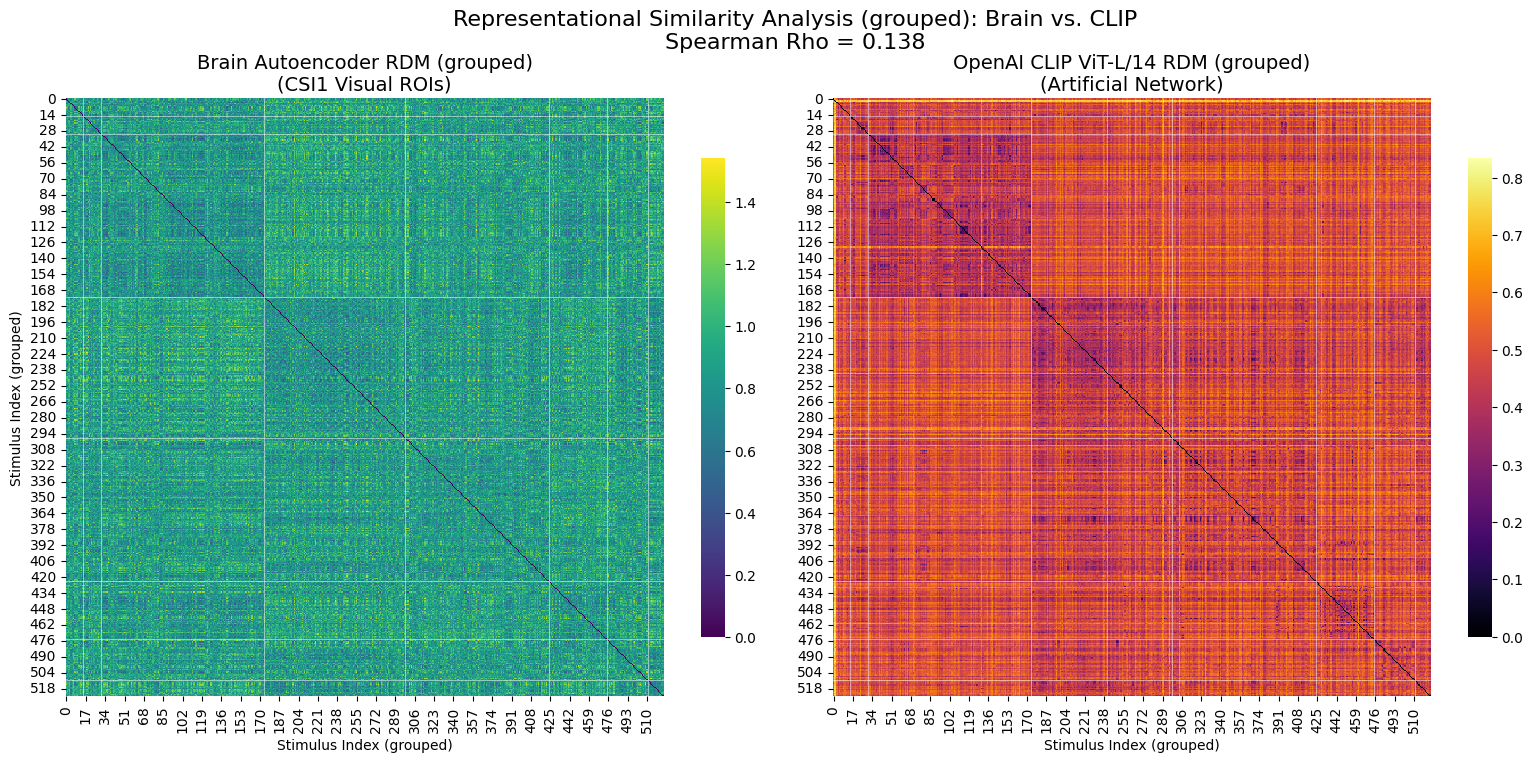

In [ ]:
# Measure how good the representations are mapped
import scipy.spatial.distance as distance

print("Building Representational Dissimilarity Matrices (RDMs)...")

# Order trials so images with the same semantic labels sit next to each other ---
import json

SEMANTIC_JSON_PATH = os.path.join("..", "SemanticLabels.json")
VISUAL_ROIS_PATH = os.path.join("..", "processed_data", SUBJECT, f"{SUBJECT}_visual_rois.npz")

# 1) Load semantic groups (coarse) -> list of fine labels
with open(SEMANTIC_JSON_PATH, "r") as f:
    semantic_map = json.load(f)

label_to_group = {}
for group, spec in semantic_map.items():
    for lbl in spec.get("labels", []):
        label_to_group[str(lbl).strip().lower()] = group
    for alias in spec.get("aliases", []):
        # Aliases aren't used directly as labels, but keeping them here makes future matching easier.
        label_to_group[str(alias).strip().lower()] = group

#  Load per-trial fine-grained labels 
vis = np.load(VISUAL_ROIS_PATH, allow_pickle=True)
vis_imgnames = vis["imgnames"]
vis_labels = vis["labels"]  # dtype object, each entry is list[str]
if len(vis_imgnames) != len(vis_labels):
    raise ValueError(f"Mismatch: imgnames={len(vis_imgnames)} vs labels={len(vis_labels)} in {VISUAL_ROIS_PATH}")

#  Map current test set -> original trial indices -> semantic group
basename_to_trial = {str(n): i for i, n in enumerate(vis_imgnames)}

def normalize_label(s: str) -> str:
    return str(s).replace("_", " ").strip().lower()

def trial_group_from_labels(label_list):
    """Return a coarse semantic group name for a trial, or None if unknown."""
    if label_list is None:
        return None
    # label_list is typically a list[str]
    for lbl in list(label_list):
        key = normalize_label(lbl)
        if key in label_to_group:
            return label_to_group[key]
    # fallback: try exact key without underscore->space transform
    for lbl in list(label_list):
        key = str(lbl).strip().lower()
        if key in label_to_group:
            return label_to_group[key]
    return None

test_basenames = np.array([os.path.basename(p) for p in test_image_paths])
trial_indices = np.array([basename_to_trial.get(n, -1) for n in test_basenames], dtype=int)
if (trial_indices < 0).any():
    missing = test_basenames[trial_indices < 0][:10]
    raise KeyError(f"Some test image names weren't found in {VISUAL_ROIS_PATH} imgnames. Example(s): {missing}")

test_groups = []
test_fine_labels = []
for ti in trial_indices:
    lbs = vis_labels[ti]
    test_fine_labels.append(lbs)
    test_groups.append(trial_group_from_labels(lbs))
test_groups = np.array(test_groups, dtype=object)

# 4) Build a stable ordering: first by group, then by first fine label, then by filename
def first_label(lbs):
    if lbs is None:
        return ""
    if isinstance(lbs, (list, tuple)) and len(lbs) > 0:
        return str(lbs[0])
    return str(lbs)

sort_keys = []
for i in range(len(test_basenames)):
    grp = test_groups[i] if test_groups[i] is not None else "zzz_unknown"
    sort_keys.append((grp, first_label(test_fine_labels[i]), str(test_basenames[i])))

order = np.array([i for i, _ in sorted(enumerate(sort_keys), key=lambda x: x[1])], dtype=int)

# Apply reordering to keep same-label images adjacent in the RSA heatmaps
final_bottlenecks_ord = final_bottlenecks[order]
clip_embeddings_ord = clip_embeddings[order]
test_image_paths_ord = test_image_paths[order]
test_groups_ord = test_groups[order]

# Optional quick summary
unique, counts = np.unique(np.array([g if g is not None else "unknown" for g in test_groups_ord]), return_counts=True)
top = sorted(zip(unique, counts), key=lambda x: x[1], reverse=True)[:10]
print("Semantic grouping (top 10 groups in test set):")
for g, c in top:
    print(f"  {g}: {c}")

# --- RDM computation on trials
fmri_rdm_condensed = distance.pdist(final_bottlenecks_ord, metric='cosine')
fmri_rdm = distance.squareform(fmri_rdm_condensed)

clip_rdm_condensed = distance.pdist(clip_embeddings_ord, metric='cosine')
clip_rdm = distance.squareform(clip_rdm_condensed)

print(f"Brain RDM Shape: {fmri_rdm.shape}")
print(f"CLIP RDM Shape: {clip_rdm.shape}")

# --- Global RSA Score (order-invariant, but we compute it over the same pairs) ---
print("\n--- Performing Global RSA Alignment Score ---")
rsa_corr, rsa_pval = spearmanr(fmri_rdm_condensed, clip_rdm_condensed)

print(f"RSA Global Alignment Score: {rsa_corr:.4f}")
print(f"P-value: {rsa_pval:.4e}")

# 4. Statistical Sanity check vs Random Alignment
num_perms = 100
null_corrs = []
for _ in range(num_perms):
    shuffled = clip_rdm_condensed.copy()
    np.random.shuffle(shuffled)
    null_corr, _ = spearmanr(fmri_rdm_condensed, shuffled)
    null_corrs.append(null_corr)

mean_null = np.mean(null_corrs)
std_null = np.std(null_corrs)
z_score = (rsa_corr - mean_null) / std_null
print(f"Z-Score against Random Permutations: {z_score:.2f}")

# --- Plotting (now grouped by semantic labels) ---
# Make a simple group boundary overlay to visually show clusters
group_ids = np.array([g if g is not None else "unknown" for g in test_groups_ord], dtype=object)
boundaries = np.where(group_ids[1:] != group_ids[:-1])[0] + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(fmri_rdm, cmap='viridis', square=True, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title(f"Brain Autoencoder RDM (grouped)\n({SUBJECT} Visual ROIs)", fontsize=14)
axes[0].set_xlabel("Stimulus Index (grouped)")
axes[0].set_ylabel("Stimulus Index (grouped)")

sns.heatmap(clip_rdm, cmap='inferno', square=True, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title("OpenAI CLIP ViT-L/14 RDM (grouped)\n(Artificial Network)", fontsize=14)
axes[1].set_xlabel("Stimulus Index (grouped)")

# Draw boundaries between semantic groups
for ax in axes:
    for b in boundaries:
        ax.axhline(b, color='white', lw=0.6, alpha=0.6)
        ax.axvline(b, color='white', lw=0.6, alpha=0.6)

plt.suptitle(f"Representational Similarity Analysis (grouped): Brain vs. CLIP\nSpearman Rho = {rsa_corr:.3f}", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()